In [ ]:
import pandas as pd
import heapq
import time
import math

In [ ]:
df = pd.read_csv("metro_rer_idf_50.csv")

df.head()

,ligne,station,ordre,correspondance,latitude,longitude
0,RER A 1,Cergy le Haut,1,NaN,49.047876,2.011000
1,RER A 1,Cergy Saint-Christophe,2,NaN,49.049647,2.034294
2,RER A 1,Cergy Préfecture,3,NaN,49.036464,2.079535
3,RER A 1,Neuville Université,4,NaN,49.014134,2.078307
4,RER A 1,Conflans Fin d’Oise,5,NaN,48.990333,2.073955


In [ ]:
graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 30


In [ ]:
def dijkstra(graph, start, goal):
    start_time = time.perf_counter()

    pq = [(0, start)]
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {}
    visited = set()
    expanded_nodes = 0

    while pq:
        current_distance, current_node = heapq.heappop(pq)

        if current_node in visited:
            continue

        visited.add(current_node)
        expanded_nodes += 1

        if current_node == goal:
            break

        for neighbor, weight in graph[current_node]:
            new_distance = current_distance + weight

            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                previous[neighbor] = current_node
                heapq.heappush(pq, (new_distance, neighbor))

    path = []
    node = goal

    if node not in previous and node != start:
        return None, float('inf'), 0, expanded_nodes, 0

    while node != start:
        path.append(node)
        node = previous[node]

    path.append(start)
    path.reverse()

    runtime = (time.perf_counter() - start_time) * 1000

    return path, len(path), distances[goal], expanded_nodes, runtime

In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

print("Source:", start)
print("Target:", goal)
print("Path Found:", "Yes" if path else "No")
print("Path Length:", path_length)
print("Total Cost:", total_cost)
print("Runtime (ms):", round(runtime, 4))
print("Explored Nodes:", explored_nodes)
print("Path:", " -> ".join(path))

Source: Cergy le Haut
Target: Cergy Saint-Christophe
Path Found: Yes
Path Length: 2
Total Cost: 1
Runtime (ms): 0.0226
Explored Nodes: 2
Path: Cergy le Haut -> Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)
    print(run, round(runtime, 4), explored_nodes, path_length, total_cost)

1 0.0308 2 2 1
2 0.0162 2 2 1
3 0.0069 2 2 1
4 0.0062 2 2 1
5 0.0059 2 2 1
6 0.0056 2 2 1
7 0.0058 2 2 1
8 0.0056 2 2 1
9 0.0056 2 2 1
10 0.0055 2 2 1
11 0.0056 2 2 1
12 0.0055 2 2 1
13 0.0056 2 2 1
14 0.0055 2 2 1
15 0.0056 2 2 1
16 0.0056 2 2 1
17 0.0055 2 2 1
18 0.0055 2 2 1
19 0.0055 2 2 1
20 0.0055 2 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Nation


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0552 27 16 15
2 0.063 27 16 15
3 0.0263 27 16 15
4 0.0237 27 16 15
5 0.0234 27 16 15
6 0.0236 27 16 15
7 0.0231 27 16 15
8 0.0229 27 16 15
9 0.0228 27 16 15
10 0.0228 27 16 15
11 0.0227 27 16 15
12 0.0227 27 16 15
13 0.0228 27 16 15
14 0.0226 27 16 15
15 0.0228 27 16 15
16 0.0228 27 16 15
17 0.0226 27 16 15
18 0.0228 27 16 15
19 0.0226 27 16 15
20 0.0229 27 16 15


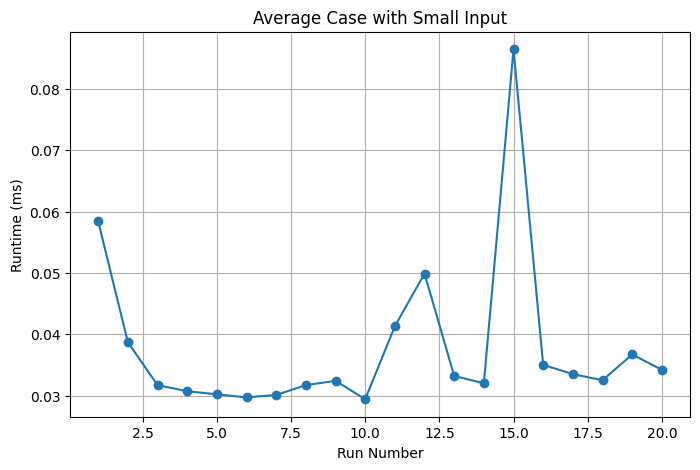

In [ ]:
import matplotlib.pyplot as plt

runs = list(range(1, 21))
runtime = [
    0.0584, 0.0387, 0.0317, 0.0307, 0.0302,
    0.0297, 0.0301, 0.0317, 0.0324, 0.0294,
    0.0413, 0.0499, 0.0332, 0.0320, 0.0865,
    0.0350, 0.0335, 0.0325, 0.0367, 0.0342
]

plt.figure(figsize=(8, 5))
plt.plot(runs, runtime, marker='o')
plt.xlabel("Run Number")
plt.ylabel("Runtime (ms)")
plt.title("Average Case with Small Input")
plt.grid(True)
plt.show()

In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Le Vésinet – Le Pecq


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0529 19 12 11
2 0.0361 19 12 11
3 0.0225 19 12 11
4 0.029 19 12 11
5 0.0183 19 12 11
6 0.018 19 12 11
7 0.0175 19 12 11
8 0.0176 19 12 11
9 0.0173 19 12 11
10 0.0171 19 12 11
11 0.0174 19 12 11
12 0.0173 19 12 11
13 0.0173 19 12 11
14 0.0171 19 12 11
15 0.0169 19 12 11
16 0.0172 19 12 11
17 0.0172 19 12 11
18 0.0171 19 12 11
19 0.017 19 12 11
20 0.0171 19 12 11


In [ ]:
df = pd.read_csv("metro_rer_idf_258.csv")

graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 93


In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0506 3 2 1
2 0.0545 3 2 1
3 0.0208 3 2 1
4 0.0198 3 2 1
5 0.0185 3 2 1
6 0.0181 3 2 1
7 0.0179 3 2 1
8 0.0178 3 2 1
9 0.0176 3 2 1
10 0.0174 3 2 1
11 0.0181 3 2 1
12 0.0175 3 2 1
13 0.0181 3 2 1
14 0.0185 3 2 1
15 0.0178 3 2 1
16 0.0172 3 2 1
17 0.0177 3 2 1
18 0.0178 3 2 1
19 0.0188 3 2 1
20 0.0285 3 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Aéroport Charles de Gaulle 2 TGV


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0719 13 5 4
2 0.045 13 5 4
3 0.0286 13 5 4
4 0.0276 13 5 4
5 0.0279 13 5 4
6 0.0265 13 5 4
7 0.026 13 5 4
8 0.0337 13 5 4
9 0.0256 13 5 4
10 0.0258 13 5 4
11 0.0258 13 5 4
12 0.0776 13 5 4
13 0.0262 13 5 4
14 0.026 13 5 4
15 0.0258 13 5 4
16 0.0258 13 5 4
17 0.0259 13 5 4
18 0.0259 13 5 4
19 0.0257 13 5 4
20 0.0258 13 5 4


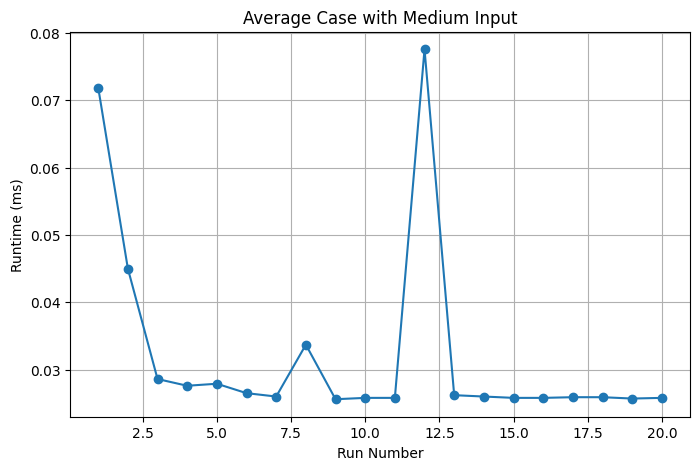

In [ ]:
import matplotlib.pyplot as plt

runs = list(range(1, 21))
runtime = [
    0.0719, 0.0450, 0.0286, 0.0276, 0.0279,
    0.0265, 0.0260, 0.0337, 0.0256, 0.0258,
    0.0258, 0.0776, 0.0262, 0.0260, 0.0258,
    0.0258, 0.0259, 0.0259, 0.0257, 0.0258
]

plt.figure(figsize=(8, 5))
plt.plot(runs, runtime, marker='o')
plt.xlabel("Run Number")
plt.ylabel("Runtime (ms)")
plt.title("Average Case with Medium Input")
plt.grid(True)
plt.show()

In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Saint-Rémy-lès-Chevreuse


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.1131 37 8 7
2 0.0727 37 8 7
3 0.0538 37 8 7
4 0.0524 37 8 7
5 0.0542 37 8 7
6 0.0499 37 8 7
7 0.0695 37 8 7
8 0.0503 37 8 7
9 0.0545 37 8 7
10 0.0492 37 8 7
11 0.0494 37 8 7
12 0.0487 37 8 7
13 0.0493 37 8 7
14 0.0495 37 8 7
15 0.0493 37 8 7
16 0.049 37 8 7
17 0.0495 37 8 7
18 0.0489 37 8 7
19 0.0491 37 8 7
20 0.0512 37 8 7


In [ ]:
df = pd.read_csv("metro_rer_idf_630.csv")

graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 181


In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0828 3 2 1
2 0.0481 3 2 1
3 0.0335 3 2 1
4 0.0323 3 2 1
5 0.0322 3 2 1
6 0.0311 3 2 1
7 0.0927 3 2 1
8 0.0346 3 2 1
9 0.0313 3 2 1
10 0.0343 3 2 1
11 0.0317 3 2 1
12 0.0321 3 2 1
13 0.0316 3 2 1
14 0.0313 3 2 1
15 0.0314 3 2 1
16 0.0308 3 2 1
17 0.0311 3 2 1
18 0.0315 3 2 1
19 0.0311 3 2 1
20 0.0308 3 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Gif-sur-Yvette


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.1771 54 10 9
2 0.1293 54 10 9
3 0.087 54 10 9
4 0.09 54 10 9
5 0.1488 54 10 9
6 0.0861 54 10 9
7 0.0828 54 10 9
8 0.082 54 10 9
9 0.0804 54 10 9
10 0.0808 54 10 9
11 0.0809 54 10 9
12 0.0812 54 10 9
13 0.0895 54 10 9
14 0.0912 54 10 9
15 0.08 54 10 9
16 0.0823 54 10 9
17 0.0798 54 10 9
18 0.08 54 10 9
19 0.0796 54 10 9
20 0.08 54 10 9


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Pierrefitte Stains


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = dijkstra(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.4857 177 23 22
2 0.3384 177 23 22
3 0.2396 177 23 22
4 0.2469 177 23 22
5 0.2245 177 23 22
6 0.2236 177 23 22
7 0.2246 177 23 22
8 0.2388 177 23 22
9 0.2238 177 23 22
10 0.2219 177 23 22
11 0.2231 177 23 22
12 0.238 177 23 22
13 0.5284 177 23 22
14 0.2549 177 23 22
15 0.2521 177 23 22
16 0.2253 177 23 22
17 0.2232 177 23 22
18 0.2339 177 23 22
19 0.2272 177 23 22
20 0.2219 177 23 22


In [ ]:
def heuristic(node, goal):
    return 1

def a_star(graph, start, goal):
    start_time = time.perf_counter()

    open_set = [(0, start)]
    came_from = {}

    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0

    f_score = {node: float('inf') for node in graph}
    f_score[start] = heuristic(start, goal)

    explored_nodes = 0
    visited = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current in visited:
            continue

        visited.add(current)
        explored_nodes += 1

        if current == goal:
            path = []

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            runtime = (time.perf_counter() - start_time) * 1000

            return (
                path,
                len(path),
                g_score[goal],
                explored_nodes,
                runtime
            )

        for neighbor, weight in graph[current]:
            tentative_g_score = g_score[current] + weight

            if tentative_g_score < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = tentative_g_score + heuristic(neighbor, goal)

                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    return None, 0, float('inf'), explored_nodes, 0

In [ ]:
df = pd.read_csv("metro_rer_idf_50.csv")

graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 30


In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0396 2 2 1
2 0.0282 2 2 1
3 0.0123 2 2 1
4 0.0109 2 2 1
5 0.0109 2 2 1
6 0.0105 2 2 1
7 0.0106 2 2 1
8 0.0107 2 2 1
9 0.0105 2 2 1
10 0.0143 2 2 1
11 0.0105 2 2 1
12 0.0103 2 2 1
13 0.0106 2 2 1
14 0.0103 2 2 1
15 0.0103 2 2 1
16 0.0104 2 2 1
17 0.0105 2 2 1
18 0.0103 2 2 1
19 0.0102 2 2 1
20 0.0138 2 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Nation


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0681 27 16 15
2 0.0558 27 16 15
3 0.0346 27 16 15
4 0.033 27 16 15
5 0.0318 27 16 15
6 0.0315 27 16 15
7 0.0313 27 16 15
8 0.0311 27 16 15
9 0.031 27 16 15
10 0.0312 27 16 15
11 0.0311 27 16 15
12 0.0309 27 16 15
13 0.0313 27 16 15
14 0.0307 27 16 15
15 0.031 27 16 15
16 0.0378 27 16 15
17 0.0311 27 16 15
18 0.0308 27 16 15
19 0.0312 27 16 15
20 0.0413 27 16 15


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Le Vésinet – Le Pecq


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0854 19 12 11
2 0.0831 19 12 11
3 0.049 19 12 11
4 0.0459 19 12 11
5 0.0443 19 12 11
6 0.0461 19 12 11
7 0.0441 19 12 11
8 0.0429 19 12 11
9 0.0467 19 12 11
10 0.0435 19 12 11
11 0.0343 19 12 11
12 0.0352 19 12 11
13 0.0453 19 12 11
14 0.0438 19 12 11
15 0.0611 19 12 11
16 0.0423 19 12 11
17 0.0426 19 12 11
18 0.0436 19 12 11
19 0.4288 19 12 11
20 0.0453 19 12 11


In [ ]:
df = pd.read_csv("metro_rer_idf_258.csv")

graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 93


In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.1016 3 2 1
2 0.083 3 2 1
3 0.0649 3 2 1
4 0.0633 3 2 1
5 0.0632 3 2 1
6 0.0631 3 2 1
7 0.0636 3 2 1
8 0.0749 3 2 1
9 0.0623 3 2 1
10 0.063 3 2 1
11 0.0632 3 2 1
12 0.0622 3 2 1
13 0.0628 3 2 1
14 0.0622 3 2 1
15 0.0619 3 2 1
16 0.0613 3 2 1
17 0.0619 3 2 1
18 0.0624 3 2 1
19 0.072 3 2 1
20 0.0617 3 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Aéroport Charles de Gaulle 2 TGV


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.0908 13 5 4
2 0.0632 13 5 4
3 0.0513 13 5 4
4 0.0489 13 5 4
5 0.0497 13 5 4
6 0.0446 13 5 4
7 0.0609 13 5 4
8 0.0468 13 5 4
9 0.0438 13 5 4
10 0.0434 13 5 4
11 0.0428 13 5 4
12 0.0453 13 5 4
13 0.0435 13 5 4
14 0.0429 13 5 4
15 0.0749 13 5 4
16 0.0498 13 5 4
17 0.0432 13 5 4
18 0.0431 13 5 4
19 0.043 13 5 4
20 0.0428 13 5 4


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Saint-Rémy-lès-Chevreuse


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.1373 37 8 7
2 0.0917 37 8 7
3 0.0749 37 8 7
4 0.0736 37 8 7
5 0.0737 37 8 7
6 0.0743 37 8 7
7 0.1011 37 8 7
8 0.0785 37 8 7
9 0.0717 37 8 7
10 0.0721 37 8 7
11 0.0715 37 8 7
12 0.0712 37 8 7
13 0.0711 37 8 7
14 0.0708 37 8 7
15 0.0711 37 8 7
16 0.0709 37 8 7
17 0.0711 37 8 7
18 0.1288 37 8 7
19 0.0774 37 8 7
20 0.072 37 8 7


In [ ]:
df = pd.read_csv("metro_rer_idf_630.csv")

graph = {}

for i in range(len(df)-1):
    station1 = df.iloc[i]['station']
    station2 = df.iloc[i+1]['station']

    graph.setdefault(station1, []).append((station2, 1))
    graph.setdefault(station2, []).append((station1, 1))

print("Number of nodes:", len(graph))

Number of nodes: 181


In [ ]:
start = list(graph.keys())[0]
goal = graph[start][0][0]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Cergy Saint-Christophe


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.1131 3 2 1
2 0.0723 3 2 1
3 0.0621 3 2 1
4 0.061 3 2 1
5 0.0631 3 2 1
6 0.0606 3 2 1
7 0.1239 3 2 1
8 0.061 3 2 1
9 0.0601 3 2 1
10 0.0601 3 2 1
11 0.0606 3 2 1
12 0.06 3 2 1
13 0.0602 3 2 1
14 0.0598 3 2 1
15 0.0594 3 2 1
16 0.0854 3 2 1
17 0.0932 3 2 1
18 0.0787 3 2 1
19 0.0605 3 2 1
20 0.0598 3 2 1


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[len(nodes)//2]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Gif-sur-Yvette


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.2204 54 10 9
2 0.1609 54 10 9
3 0.184 54 10 9
4 0.1377 54 10 9
5 0.1245 54 10 9
6 0.1284 54 10 9
7 0.1376 54 10 9
8 0.1536 54 10 9
9 0.1566 54 10 9
10 0.1341 54 10 9
11 0.1254 54 10 9
12 0.1223 54 10 9
13 0.1217 54 10 9
14 0.1218 54 10 9
15 0.1228 54 10 9
16 0.1242 54 10 9
17 0.1206 54 10 9
18 0.1208 54 10 9
19 0.2838 54 10 9
20 0.177 54 10 9


In [ ]:
nodes = list(graph.keys())

start = nodes[0]
goal = nodes[-1]

print("Source:", start)
print("Target:", goal)

Source: Cergy le Haut
Target: Pierrefitte Stains


In [ ]:
for run in range(1, 21):
    path, path_length, total_cost, explored_nodes, runtime = a_star(graph, start, goal)

    print(
        run,
        round(runtime, 4),
        explored_nodes,
        path_length,
        total_cost
    )

1 0.8674 177 23 22
2 0.7021 177 23 22
3 0.5442 177 23 22
4 0.5678 177 23 22
5 0.5187 177 23 22
6 0.5549 177 23 22
7 0.5583 177 23 22
8 0.5432 177 23 22
9 0.5921 177 23 22
10 0.6259 177 23 22
11 0.5607 177 23 22
12 0.5485 177 23 22
13 0.5737 177 23 22
14 0.5283 177 23 22
15 0.5373 177 23 22
16 0.613 177 23 22
17 0.6854 177 23 22
18 1.2153 177 23 22
19 2.2346 177 23 22
20 0.551 177 23 22
